In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
torch.manual_seed(0)
from mnist import get_mnist_loaders
from LeNet import LeNet
import symo.optim2 as symo_optim
from symo.group import S, B, I, O
from symo.factory2 import GroupsSpec, groups_spec

from dataclasses import dataclass, asdict
import copy
# ------------------------
# Training / Eval
# ------------------------
def train_epoch(model, loader, optimizer, criterion, device, max_iter = None):
    if max_iter == None:
        max_iter = len(loader)
    model.train()
    total_loss = 0
    losses = []
    counter = 0

    for x, y in loader:
        if counter == max_iter:
            return total_loss / max_iter, losses
        counter += 1
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        losses += [loss.item()]


    return total_loss / len(loader), losses


def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            preds = logits.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

def print_model_params(model):
    total = 0

    for name, param in model.named_parameters():
        if param.requires_grad:
            n = param.numel()
            total += n

            shape = str(tuple(param.shape))  # <-- fix

            print(f"{name:20s} | shape: {shape:15s} | params: {n}")

    print("-" * 60)
    print(f"Total trainable params: {total}")


@dataclass(frozen=True)
class SymoConfig:
    num_epochs: int = 300
    grads_beta: float = 0.8
    factors_beta: float = 0.0
    grads_bias_corr: bool = True
    factors_bias_corr: bool = False
    update_correction: bool = True
    damping: float = 1.0e-09
    lr: float = 0.001
    sub_group_avg: bool = (False,)
    update_avg: bool = (False,)
    decomp_precision: str = "fp64"
    block_diag: bool = True
# ------------------------
# Main
# ------------------------

In = "I_input"
G1 = "B_L1"
G2 =  "I_L2"
G3 = "I_L3"
G4 = "B_L4"
G5 = "B_L5"
Ou = "I_output"

sizes = dict(input = 1,
            L1 = 6,
            L2 = 16,
            L3 = 256,
            L4 = 120,
            L5 = 84,
            output = 10,
             H1 = 5,
             W1 = 5,
            H2 = 5,
             W2 = 5 )

Ih = "I_H1"
Iw = "I_W1"
Ih2 = "I_H2"
Iw2 = "I_W2"

groups_cfg = dict(
    [
        ("conv1.weight",(G1,In,Iw,Ih)),
        ("conv1.bias",(G1,)),
        ("conv2.weight",(G2,G1,Iw2,Ih2)),
        ("conv2.bias",(G2,)),
        ("fc1.weight", (G4,G3)),
        ("fc1.bias",(G4,)),
        ("fc2.weight", (G5,G4)),
        ("fc2.bias",(G5,)),
        ("fc3.weight", (Ou,G5)),
        ("fc3.bias",(Ou,)),
        
    ]
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LeNet(activation="tanh").to(device)
state = model.state_dict()
state = copy.deepcopy(state)

group_spec_ord = [groups_cfg[n] for n, _ in model.named_parameters()]

spec = groups_spec(group_spec_ord, sizes)

symo_cfg = SymoConfig()
opt_dict = asdict(symo_cfg)
opt_dict.pop("num_epochs")


def main(opt='adam'):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # Import loaders
    train_loader, test_loader = get_mnist_loaders()

    model = LeNet(activation="tanh").to(device)

    model.load_state_dict(state)

    if opt == 'symo':
        optimizer = symo_optim.Symo(
            model.parameters(),
            groups_spec=spec,
            **opt_dict,
        )
    else:
        optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    epochs = 15

    losses = []

    for epoch in range(1, epochs + 1):
        loss,losses_ = train_epoch(model, train_loader, optimizer, criterion, device)
        losses += losses_
        train_acc = evaluate(model,train_loader,device)
        acc = evaluate(model, test_loader, device)
        print(f"Epoch {epoch:02d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {acc:.4f}")


    return losses, model.state_dict()




In [2]:
symo_losses, symo_map_state = main('symo')

Using device: cuda
Epoch 01 | Loss: 0.3309 | Train Acc: 0.9821 | Test Acc: 0.9815
Epoch 02 | Loss: 0.0509 | Train Acc: 0.9907 | Test Acc: 0.9848
Epoch 03 | Loss: 0.0327 | Train Acc: 0.9942 | Test Acc: 0.9865
Epoch 04 | Loss: 0.0222 | Train Acc: 0.9953 | Test Acc: 0.9853
Epoch 05 | Loss: 0.0161 | Train Acc: 0.9978 | Test Acc: 0.9880
Epoch 06 | Loss: 0.0121 | Train Acc: 0.9979 | Test Acc: 0.9877
Epoch 07 | Loss: 0.0089 | Train Acc: 0.9977 | Test Acc: 0.9860
Epoch 08 | Loss: 0.0075 | Train Acc: 0.9990 | Test Acc: 0.9873
Epoch 09 | Loss: 0.0071 | Train Acc: 0.9986 | Test Acc: 0.9869
Epoch 10 | Loss: 0.0057 | Train Acc: 0.9990 | Test Acc: 0.9851
Epoch 11 | Loss: 0.0050 | Train Acc: 0.9990 | Test Acc: 0.9868
Epoch 12 | Loss: 0.0053 | Train Acc: 0.9992 | Test Acc: 0.9865
Epoch 13 | Loss: 0.0053 | Train Acc: 0.9989 | Test Acc: 0.9858
Epoch 14 | Loss: 0.0043 | Train Acc: 0.9990 | Test Acc: 0.9861
Epoch 15 | Loss: 0.0045 | Train Acc: 0.9995 | Test Acc: 0.9876


In [3]:
adam_losses, adam_map_state = main('adam')
del adam_map_state

Using device: cuda
Epoch 01 | Loss: 0.2947 | Train Acc: 0.9772 | Test Acc: 0.9788
Epoch 02 | Loss: 0.0659 | Train Acc: 0.9867 | Test Acc: 0.9847
Epoch 03 | Loss: 0.0457 | Train Acc: 0.9902 | Test Acc: 0.9870
Epoch 04 | Loss: 0.0347 | Train Acc: 0.9921 | Test Acc: 0.9867
Epoch 05 | Loss: 0.0272 | Train Acc: 0.9930 | Test Acc: 0.9869
Epoch 06 | Loss: 0.0220 | Train Acc: 0.9951 | Test Acc: 0.9876
Epoch 07 | Loss: 0.0196 | Train Acc: 0.9957 | Test Acc: 0.9879
Epoch 08 | Loss: 0.0145 | Train Acc: 0.9972 | Test Acc: 0.9873
Epoch 09 | Loss: 0.0110 | Train Acc: 0.9978 | Test Acc: 0.9881
Epoch 10 | Loss: 0.0093 | Train Acc: 0.9974 | Test Acc: 0.9887
Epoch 11 | Loss: 0.0099 | Train Acc: 0.9983 | Test Acc: 0.9883
Epoch 12 | Loss: 0.0079 | Train Acc: 0.9989 | Test Acc: 0.9880
Epoch 13 | Loss: 0.0058 | Train Acc: 0.9978 | Test Acc: 0.9883
Epoch 14 | Loss: 0.0060 | Train Acc: 0.9965 | Test Acc: 0.9850
Epoch 15 | Loss: 0.0070 | Train Acc: 0.9981 | Test Acc: 0.9863


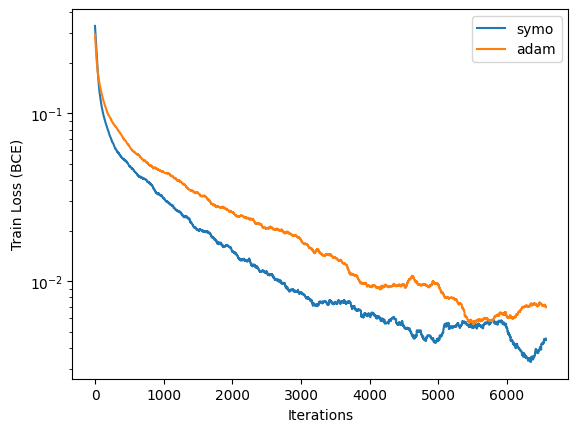

In [4]:
from matplotlib import pyplot as plt
def rolling_average(data, window):
    if not data or window <= 0: return []
    
    # Calculate first window sum
    current_sum = sum(data[:window])
    results = [current_sum / window]
    
    # Slide the window: add next, subtract previous
    for i in range(len(data) - window):
        current_sum += data[i + window] - data[i]
        results.append(current_sum / window)
        
    return results
plt.plot(rolling_average(symo_losses,469),label='symo')
plt.plot(rolling_average(adam_losses,469),label='adam')
plt.yscale('log')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Train Loss (BCE)')
plt.show()


In [ ]:
import symo_diff

num_samples = 5
num_steps = 20

@dataclass(frozen=True)

class SymoDiffConfig:
    num_epochs: int = 300
    grads_beta: float = 0.0
    factors_beta: float = 0.0
    grads_bias_corr: bool = True
    factors_bias_corr: bool = False
    update_correction: bool = True
    damping: float = 1.0e-09
    prior_alpha: float = 1.0
    lr: float = 0.001/num_steps**0.5
    sub_group_avg: bool = (False,)
    update_avg: bool = (False,)
    decomp_precision: str = "fp64"
    block_diag: bool = True


symodiff_cfg = SymoDiffConfig()
opt_dict = asdict(symodiff_cfg)
opt_dict.pop("num_epochs")

model = LeNet(activation="tanh").to(device)


criterion = nn.CrossEntropyLoss()

train_loader, test_loader = get_mnist_loaders(batch_size=128)


for s in range(1,num_samples):
    print('sample',s)
    model.load_state_dict(symo_map_state)


    sampler = symo_diff.Symo(
            model.parameters(),
            groups_spec=spec,
            **opt_dict,
        )
    for epoch in range(1, num_steps):
        loss, _ = train_epoch(model, train_loader, sampler, criterion, device,max_iter = 1)
        print(loss)



    
    


